# Twitter US Airline Sentiment AnalysisClassify airline tweets as **negative**, **neutral**, or **positive** using classical NLP + Machine Learning.**Pipeline:** load data -> filter low-confidence labels -> clean text (NLTK) -> encode labels -> vectorize (Bag-of-Words / TF-IDF) -> train Multinomial Naive Bayes -> evaluate -> save model.**Dataset:** [Twitter US Airline Sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment).

## 1. Install & import dependencies

In [3]:
import re
import string
import warnings
import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (    ConfusionMatrixDisplay,    accuracy_score,    classification_report,    confusion_matrix,)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("Imports ready.")

Imports ready.


In [5]:
# NLTK corpora required for stopword removal and lemmatizationfor resource in ("stopwords", "wordnet", "omw-1.4"):    nltk.download(resource, quiet=True)print("NLTK resources downloaded.")

## 2. Load the dataset

In [4]:
DATA_PATH = "/content/Tweets.csv"   # change if your CSV lives elsewheresentiment_data = pd.read_csv(DATA_PATH)print(f"Shape: {sentiment_data.shape}")sentiment_data.head()

In [9]:
sentiment_data= pd.read_csv(DATA_PATH)

In [10]:
sentiment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [ ]:
# Only two columns actually matter for modelling, plus the confidence scoresentiment_data[["airline_sentiment", "airline_sentiment_confidence", "airline", "text"]].head(10)

## 3. Exploratory data analysis

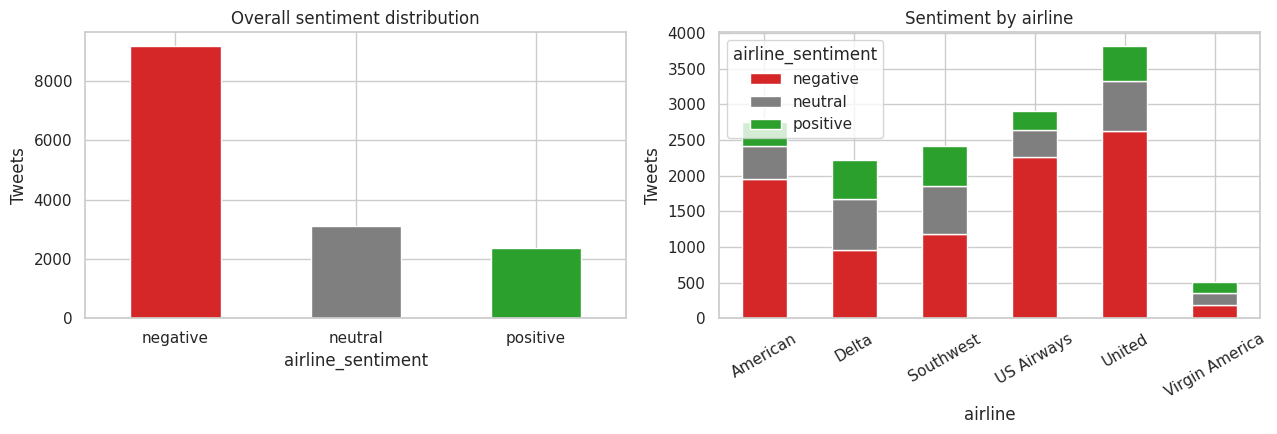

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sentiment_data["airline_sentiment"].value_counts().plot(    kind="bar", ax=axes[0], color=["#d62728", "#7f7f7f", "#2ca02c"], rot=0)
axes[0].set_title("Overall sentiment distribution")
axes[0].set_ylabel("Tweets")
pd.crosstab(sentiment_data["airline"], sentiment_data["airline_sentiment"]).plot(    kind="bar", stacked=True, ax=axes[1], rot=30,    color=["#d62728", "#7f7f7f", "#2ca02c"],)
axes[1].set_title("Sentiment by airline")
axes[1].set_ylabel("Tweets")
plt.tight_layout()
plt.show()

## 4. Filter low-confidence labelsEach label was crowd-annotated and comes with a confidence score. Rows below `0.5`are essentially noise, so we drop them before training.

In [13]:
CONFIDENCE_THRESHOLD = 0.5
sentiment_df = sentiment_data[sentiment_data["airline_sentiment_confidence"] >= CONFIDENCE_THRESHOLD].reset_index(drop=True)
print(f"Before: {sentiment_data.shape[0]:,} rows")
print(f"After : {sentiment_df.shape[0]:,} rows")
print(f"Dropped {sentiment_data.shape[0] - sentiment_df.shape[0]:,} low-confidence rows")

Before: 14,640 rows
After : 14,404 rows
Dropped 236 low-confidence rows


## 5. Create X (text) and y (labels)

In [14]:
X = sentiment_df["text"]
Y = sentiment_df["airline_sentiment"]
X.head()

,text
0,@VirginAmerica What @dhepburn said.
1,@VirginAmerica I didn't today... Must mean I need to take another trip!
2,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl..."
3,@VirginAmerica and it's a really big bad thing about it
4,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's really the only bad t...


## 6. Text cleaningFor every tweet we:1. remove URLs and `@mentions`2. strip everything that is not a letter (digits, emoji, punctuation)3. lowercase and split into tokens4. drop English stopwords and 1-character tokens5. lemmatize (`completing` -> `complete`)

In [17]:
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


stop_words = set(stopwords.words("english"))
punctuations = set(string.punctuation)
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z]")


def clean_text(text: str) -> str:
    """
    Clean a single tweet and return space-separated lemmas.
    """
    if not isinstance(text, str):
        return ""

    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text)

    tokens = text.lower().split()

    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if (
            token not in stop_words
            and token not in punctuations
            and len(token) > 1
        )
    ]

    return " ".join(tokens)


# Quick sanity check
sample = "@united I waited 3 hours!! Worst service ever http://t.co/abc"

print("Raw    :", sample)
print("Cleaned:", clean_text(sample))

Raw    : @united I waited 3 hours!! Worst service ever http://t.co/abc
Cleaned: waited hour worst service ever


In [18]:
clean_data = [clean_text(text) for text in X]

preview = pd.DataFrame({
    "original": X.head(5).values,
    "cleaned": clean_data[:5],
})

preview

,original,cleaned
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica I didn't today... Must mean I need to take another trip!,today must mean need take another trip
2,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl...",really aggressive blast obnoxious entertainment guest face amp little recourse
3,@VirginAmerica and it's a really big bad thing about it,really big bad thing
4,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's really the only bad t...,seriously would pay flight seat playing really bad thing flying va


## 7. Encode the labels`negative -> 0`, `neutral -> 1`, `positive -> 2`

In [19]:
sentiments = [
    "negative",
    "neutral",
    "positive",
]

Y_encoded = Y.apply(sentiments.index)

label_counts = Y_encoded.value_counts().sort_index()

label_counts

,count
airline_sentiment,
0,9115
1,2997
2,2292


## 8. Vectorize the text`CountVectorizer` turns each tweet into a bag-of-words count vector. We cap thevocabulary at 5,000 features, allow bigrams, and blacklist airline handles(they identify the airline, not the sentiment).

In [20]:
AIRLINE_STOPWORDS = [
    "virginamerica",
    "united",
    "southwestair",
    "jetblue",
    "usairways",
    "americanair",
    "flight",
    "flights",
    "airline",
    "airlines",
]


count_vectorizer = CountVectorizer(
    max_features=5000,
    stop_words=AIRLINE_STOPWORDS,
    ngram_range=(1, 2),
    min_df=2,
)


X_fit = count_vectorizer.fit_transform(clean_data)

print("Feature matrix:", X_fit.shape)
print(
    "Sample features:",
    count_vectorizer.get_feature_names_out()[:15],
)

Feature matrix: (14404, 5000)
Sample features: ['aa' 'aa amp' 'aa customer' 'aa dfw' 'aadvantage' 'abc' 'ability' 'able'
 'able get' 'able help' 'able use' 'abq' 'absolute' 'absolute worst'
 'absolutely']


## 9. Train / test split

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(    X_fit, Y_encoded, test_size=0.3, random_state=42, stratify=Y_encoded)
print(f"Train: {X_train.shape[0]:,}")
print(f"Test : {X_test.shape[0]:,}")

Train: 10,082
Test : 4,322


## 10. Train the model`MultinomialNB` is a Naive Bayes variant built for discrete count features.It estimates `P(word | class)` from training counts and applies Bayes' rule,which makes it a fast, strong baseline for bag-of-words text classification.

In [23]:
model = MultinomialNB(alpha=1.0)
model.fit(X_train, Y_train)

MultinomialNB()

## 11. Evaluate

In [24]:
Y_pred = model.predict(X_test)
print(f"Test accuracy: {accuracy_score(Y_test, Y_pred):.4f}\n")
print(classification_report(Y_test, Y_pred, target_names=sentiments, digits=4))

Test accuracy: 0.7661

              precision    recall  f1-score   support

    negative     0.8323    0.8640    0.8479      2735
     neutral     0.5850    0.5128    0.5465       899
    positive     0.7007    0.7078    0.7043       688

    accuracy                         0.7661      4322
   macro avg     0.7060    0.6949    0.6996      4322
weighted avg     0.7599    0.7661    0.7623      4322



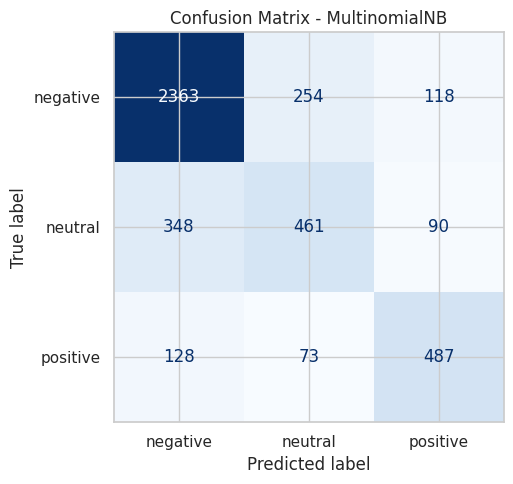

In [25]:
cm = confusion_matrix(Y_test, Y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=sentiments).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix - MultinomialNB")
plt.tight_layout()
plt.show()

In [ ]:
# 5-fold cross-validation gives a more trustworthy estimate than a single splitcv_scores = cross_val_score(MultinomialNB(), X_fit, Y_encoded, cv=5, scoring="accuracy")print("Fold scores:", cv_scores.round(4))print(f"Mean accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

## 12. What is the model actually learning?

In [26]:
feature_names = np.array(
    count_vectorizer.get_feature_names_out()
)

for idx, label in enumerate(sentiments):
    top_features = np.argsort(
        model.feature_log_prob_[idx]
    )[-15:][::-1]

    print(
        f"{label:>8}: "
        f"{', '.join(feature_names[top_features])}"
    )

negative: hour, get, cancelled, customer, service, time, bag, hold, plane, help, delayed, call, still, amp, customer service
 neutral: get, please, need, help, thanks, would, know, dm, ticket, way, time, cancelled, fleek, fleet fleek, tomorrow
positive: thanks, thank, great, service, love, guy, customer, good, best, time, get, got, much, awesome, customer service


## 13. Compare against other classifiersNaive Bayes is the baseline. Logistic Regression and a linear SVM usuallysqueeze out a few more points on TF-IDF features.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import pandas as pd


tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=AIRLINE_STOPWORDS,
    ngram_range=(1, 2),
    min_df=2,
)

X_tfidf = tfidf.fit_transform(clean_data)

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_tfidf,
    Y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=Y_encoded,
)


candidates = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
    ),
    "LinearSVC": LinearSVC(
        class_weight="balanced",
    ),
}


results = {}

for name, clf in candidates.items():
    clf.fit(Xt_train, yt_train)

    predictions = clf.predict(Xt_test)
    results[name] = accuracy_score(yt_test, predictions)


results_df = (
    pd.Series(results)
    .sort_values(ascending=False)
    .round(4)
    .to_frame("accuracy (tfidf)")
)

results_df

,accuracy (tfidf)
LinearSVC,0.7716
LogisticRegression,0.7545
MultinomialNB,0.7427


## 14. Predict on new text

In [28]:
def predict_sentiment(texts):
    cleaned = [clean_text(text) for text in texts]
    features = count_vectorizer.transform(cleaned)

    predictions = model.predict(features)
    probabilities = model.predict_proba(features)

    return pd.DataFrame({
        "text": texts,
        "prediction": [sentiments[p] for p in predictions],
        "confidence": probabilities.max(axis=1).round(3),
    })


samples = [
    "Thank you for the smooth flight and the friendly crew!",
    "My luggage was lost and nobody is answering the helpline.",
    "Flight lands at 6pm at terminal 3.",
    "Worst airline experience of my life, delayed 5 hours with no explanation.",
]

results = predict_sentiment(samples)
results

,text,prediction,confidence
0,Thank you for the smooth flight and the friendly crew!,positive,0.999
1,My luggage was lost and nobody is answering the helpline.,negative,0.999
2,Flight lands at 6pm at terminal 3.,negative,0.819
3,"Worst airline experience of my life, delayed 5 hours with no explanation.",negative,1.000


## 15. Save the model for reuse

In [29]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/sentiment_model.joblib")
joblib.dump(count_vectorizer, "models/vectorizer.joblib")

print("Saved to models/")

Saved to models/
